# 4. Network Inference and Edge Topology: Single-Cell (ROLS + FPTU)

Merges single-cell network inference as well as edge inference/external validation. ROLS and FPTU run entirely on Sonic and this notebook only loads and post-processes their output.

**Naming:** `r_rols`/`r_minv_rols` (single-cell local/global response), `r_fptu`/`r_total`/`r_minv_total` (FPTU-extended). All read from `../Results/checkpoints/{CONDITION}`, produced by the Sonic scripts (`1_prep_stv.py`, `2_rols.py`, `3_fptu.py`). This notebook's own outputs go to `../Results/{CONDITION}/singlecell`, parallel to Notebook 3's `pseudobulk` folder.

### 1. Configuration

In [1]:
import os
print(f'Working directory: {os.getcwd()}')

Working directory: /mnt/R0/Projects/POIAZ/Ilaria/Scripts


Paths, edge-calling threshold, and external validation reference files. Must match Notebooks 1-3 (`CONDITION`, `DONORS`).

In [2]:
# Must match Notebooks 1-3
CONDITION = 'Stim48hr'  # 'Rest', 'Stim8hr', 'Stim48hr'
DONORS = ['D1', 'D2', 'D3', 'D4']
donors_tag = '_'.join(DONORS)
run_tag = f'{CONDITION}_{donors_tag}'

# Paths
DATA_DIR = '../Data'
ROLS_DIR = f'../Results/checkpoints/{CONDITION}' # Sonic output (read-only from here)
CORE_GENES_DIR = f'../Results/{CONDITION}' # Notebook 2 output
PSEUDOBULK_DIR = f'../Results/{CONDITION}/pseudobulk' # Notebook 3 output
OUT_DIR = f'../Results/{CONDITION}/singlecell' # this notebook's own outputs
os.makedirs(OUT_DIR, exist_ok=True)

# Edge-calling threshold on |r_rols| off-diagonal. A single fixed value is used for the
# actual network (node table, graph, KEGG/STRING/TRRUST checks) STRENGTH_PERCENTILE_SWEEP
# below is a separate sensitivity check, only affects the validation summary table.
STRENGTH_PERCENTILE = 95
STRENGTH_PERCENTILE_SWEEP = [80, 90, 95, 99]

# Display parameters
HUB_DEGREE_LABEL_MIN = 3
TOP_N_GRAPH = 30 # network figure restricted to this many genes (by |DPD_stim_norm|) + DPD modules

# Genes to check for presence in the network
CHECKPOINT_GENES = ['PTPN11', 'PTPN6', 'PDCD1', 'BTLA']

# KEGG TCR signaling pathway reference (hsa04660)
KEGG_PATHWAY_FILE = os.path.join(DATA_DIR, 'hsa04660.xml')
KEGG_PATHWAY_ID = 'hsa04660'
KEGG_PATHWAY_NAME = 'T cell receptor signaling pathway'

# STRING / TRRUST external validation
STRING_LINKS_FILE = os.path.join(DATA_DIR, '9606.protein.links.v12.0.txt.gz')
STRING_INFO_FILE = os.path.join(DATA_DIR, '9606.protein.info.v12.0.txt.gz')
TRRUST_FILE = os.path.join(DATA_DIR, 'trrust_rawdata.human.tsv')
STRING_SCORE_HIGH = 700 # high confidence combined_score
STRING_SCORE_MED = 400 # medium confidence combined_score

print(f'run_tag: {run_tag}')
print(f'ROLS dir (input): {ROLS_DIR}')
print(f'Out dir: {OUT_DIR}')

run_tag: Stim48hr_D1_D2_D3_D4
ROLS dir (input): ../Results/checkpoints/Stim48hr
Out dir: ../Results/Stim48hr/singlecell


In [3]:
import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import hypergeom
import xml.etree.ElementTree as ET
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
print('Packages loaded.')

Packages loaded.


### 2. Load Data

Core genes and DPD scores from Notebook 2, then `r_rols`/`r_minv_rols` (ROLS) and `r_fptu`/`r_total`/`r_minv_total` (FPTU) from Sonic.

In [4]:
core_df = pd.read_csv(os.path.join(CORE_GENES_DIR, f'core_genes_{run_tag}.csv'))
dpd_stim_lookup = core_df.set_index('target_contrast_gene_name')['DPD_stim_norm']

r_rols = pd.read_csv(os.path.join(ROLS_DIR, f'r_rols_{run_tag}.csv'), index_col=0)
r_minv_rols = pd.read_csv(os.path.join(ROLS_DIR, f'r_minv_rols_{run_tag}.csv'), index_col=0)
r_fptu = pd.read_csv(os.path.join(ROLS_DIR, f'r_fptu_{run_tag}.csv'), index_col=0)
r_total = pd.read_csv(os.path.join(ROLS_DIR, f'r_total_{run_tag}.csv'), index_col=0)
r_minv_total = pd.read_csv(os.path.join(ROLS_DIR, f'r_minv_total_{run_tag}.csv'), index_col=0)

core_genes = r_rols.index.tolist()
N = len(core_genes)
dpd_module_names = r_fptu.index.tolist()

missing_from_sc = sorted(set(core_df['target_contrast_gene_name']) - set(core_genes))
if missing_from_sc:
    print(f'{len(missing_from_sc)} pseudobulk-selected genes absent from the single-cell '
          f'network (no usable Sonic data): {missing_from_sc}')

print(f'Single-cell core genes: {N}')
print(f'DPD modules (FPTU): {dpd_module_names}')
print(f'r_rols: {r_rols.shape}, r_total: {r_total.shape}')

Single-cell core genes: 200
DPD modules (FPTU): ['DPD_stim']
r_rols: (200, 200), r_total: (201, 201)


### 3. Edges from r_rols

`r_rols[target, source]` is the direct effect of `source` on `target` (standard MRA local-response convention, same row/column meaning as `r`/`r_total` in Notebook 3). An edge is called where `|r_rols|` exceeds the `STRENGTH_PERCENTILE`-th percentile of the off-diagonal values. FPTU edges into the DPD modules (from `r_fptu`) are always included regardless of this threshold, there are only a handful of them and they answer a different question (which genes drive the overall readout) than the gene-gene network does.

In [5]:
off_diag = r_rols.to_numpy()[~np.eye(N, dtype=bool)]
threshold = np.percentile(np.abs(off_diag), STRENGTH_PERCENTILE)
print(f'Edge strength threshold (top {100 - STRENGTH_PERCENTILE}% by |r_rols|): {threshold:.4f}')

def strength_edges(r_df, gene_list, thr):
    rows = []
    for target in gene_list:
        for source in gene_list:
            if source == target:
                continue
            strength = r_df.loc[target, source]
            if abs(strength) >= thr and strength != 0:
                rows.append({
                    'source': source, 'target': target, 'rols_strength': strength,
                    'edge_type': 'activation' if strength > 0 else 'inhibition',
                })
    return pd.DataFrame(rows)

edges_gene = strength_edges(r_rols, core_genes, threshold)
print(f'Gene-gene edges: {len(edges_gene)}')

edges_fptu = []
for module in dpd_module_names:
    for source in core_genes:
        strength = r_fptu.loc[module, source]
        if strength != 0:
            edges_fptu.append({
                'source': source, 'target': module, 'rols_strength': strength,
                'edge_type': 'activation' if strength > 0 else 'inhibition',
            })
edges_fptu = pd.DataFrame(edges_fptu)
print(f'DPD module edges (always included): {len(edges_fptu)}')

edges_df = pd.concat([edges_gene, edges_fptu], ignore_index=True)
print(f'Total edges: {len(edges_df)}')

Edge strength threshold (top 5% by |r_rols|): 0.0272
Gene-gene edges: 1990
DPD module edges (always included): 6
Total edges: 1996


### 4. Node Attribute Table

One row per single-cell core gene: DPD scores, biological role, and degree from `edges_df` above. Node table for the network figure and for Notebook 5.

In [6]:
node_df = core_df[core_df['target_contrast_gene_name'].isin(core_genes)][[
    'target_contrast_gene_name', 'DPD_stim_norm',
    'n_sig_genes', 'ontarget_significant', 'offtarget_flag'
]].copy().rename(columns={'target_contrast_gene_name': 'gene'})
node_df = node_df.set_index('gene').reindex(core_genes).reset_index()

node_df['role_stim'] = node_df['DPD_stim_norm'].apply(
    lambda x: 'activator' if x > 0 else 'suppressor')

node_df['out_degree'] = node_df['gene'].map(
    edges_df['source'].value_counts()).fillna(0).astype(int)
node_df['in_degree'] = node_df['gene'].map(
    edges_df['target'].value_counts()).fillna(0).astype(int)
node_df['total_degree'] = node_df['out_degree'] + node_df['in_degree']

sos = (r_minv_rols.to_numpy() ** 2).sum(axis=1)
node_df['r_minv_influence'] = pd.Series(sos, index=r_minv_rols.index).reindex(core_genes).values

node_df = node_df.sort_values('total_degree', ascending=False)
print(f'Node table: {len(node_df)} genes')
print(node_df.head(15).to_string(index=False))

Node table: 200 genes
   gene  DPD_stim_norm  n_sig_genes  ontarget_significant  offtarget_flag  role_stim  out_degree  in_degree  total_degree  r_minv_influence
PLEKHG1       0.448622          331                  True           False  activator           5        121           126        109.946555
ANKRD61      -1.497725          733                  True           False suppressor           2        118           120        200.501538
   MRC2      -0.792248          977                  True           False suppressor          49         60           109         48.416343
    AHR       0.436216         1306                  True           False  activator          52         56           108         23.868131
    ID2      -0.625626          291                  True           False suppressor          41         54            95         12.134912
 ZNF837      -0.791211          471                  True           False suppressor           5         89            94         75.10806

### 5. Network Summary

In [7]:
gene_to_idx = {g: i for i, g in enumerate(core_genes)}
r_rols_arr = r_rols.to_numpy()

n_act = (edges_gene['edge_type'] == 'activation').sum()
n_inh = (edges_gene['edge_type'] == 'inhibition').sum()
density = len(edges_gene) / (N * (N - 1))

print(f'{run_tag}')
print(f'Nodes: {N}')
print(f'Gene-gene edges: {len(edges_gene)} (activation={n_act}, inhibition={n_inh})')
print(f'Density: {density:.4f}')
for module in dpd_module_names:
    n_module = (edges_fptu['target'] == module).sum()
    print(f'{module} edges: {n_module}')

top_src = edges_gene['source'].value_counts().head(5) if not edges_gene.empty else pd.Series(dtype=int)
print('\nTop 5 sources (out-degree):')
for g, d in top_src.items():
    print(f'  {g:<10} out={d}  DPD_stim={dpd_stim_lookup.get(g, float("nan")):+.3f}')

top_tgt = edges_gene['target'].value_counts().head(5) if not edges_gene.empty else pd.Series(dtype=int)
print('\nTop 5 targets (in-degree):')
for g, d in top_tgt.items():
    print(f'  {g:<10} in={d}   DPD_stim={dpd_stim_lookup.get(g, float("nan")):+.3f}')

Stim48hr_D1_D2_D3_D4
Nodes: 200
Gene-gene edges: 1990 (activation=1397, inhibition=593)
Density: 0.0500
DPD_stim edges: 6

Top 5 sources (out-degree):
  CCNC       out=64  DPD_stim=-1.033
  DOP1B      out=59  DPD_stim=+1.401
  RASAL3     out=57  DPD_stim=+0.514
  AHR        out=52  DPD_stim=+0.436
  MRC2       out=49  DPD_stim=-0.792

Top 5 targets (in-degree):
  PLEKHG1    in=121   DPD_stim=+0.449
  ANKRD61    in=118   DPD_stim=-1.498
  ZNF837     in=89   DPD_stim=-0.791
  LOXL2      in=76   DPD_stim=-0.625
  MRC2       in=60   DPD_stim=-0.792


### 6. ROLS vs Pseudobulk Comparison

Direct answer to the original question of whether pseudobulk and single-cell DPD/network signal agree. Two checks, both on the full matrices rather than a restricted edge subset, so the comparison isn't skewed by Notebook 3's figure-only gene restriction: Pearson correlation on raw `r_minv` values (off-diagonal), and Spearman correlation on node degree, recomputed for the pseudobulk side at the same `STRENGTH_PERCENTILE` so both sides use an identical edge-calling rule.

In [8]:
r_minv_pseudo = pd.read_csv(os.path.join(PSEUDOBULK_DIR, f'r_minv_{run_tag}.csv'), index_col=0)
r_pseudo = pd.read_csv(os.path.join(PSEUDOBULK_DIR, f'r_{run_tag}.csv'), index_col=0)

shared = [g for g in core_genes if g in r_minv_pseudo.index]
print(f'Shared genes (single-cell and pseudobulk core sets): {len(shared)} / {N}')

off = ~np.eye(len(shared), dtype=bool)
rm_sc = r_minv_rols.reindex(index=shared, columns=shared).to_numpy()
rm_pb = r_minv_pseudo.reindex(index=shared, columns=shared).to_numpy()
pearson_r = np.corrcoef(rm_sc[off], rm_pb[off])[0, 1]
print(f'\nr_minv comparison (single-cell vs pseudobulk, {len(shared)} shared genes)')
print(f'  Pearson r (off-diagonal): {pearson_r:.4f}')
print(f'  Single-cell r_minv range: [{rm_sc.min():.3f}, {rm_sc.max():.3f}]')
print(f'  Pseudobulk r_minv range: [{rm_pb.min():.3f}, {rm_pb.max():.3f}]')

rm_sc_local = r_rols.reindex(index=shared, columns=shared).to_numpy()
rm_pb_local = r_pseudo.reindex(index=shared, columns=shared).to_numpy()
pearson_r_local = np.corrcoef(rm_sc_local[off], rm_pb_local[off])[0, 1]
print(f'\nr (local) comparison (single-cell vs pseudobulk, {len(shared)} shared genes)')
print(f'  Pearson r (off-diagonal): {pearson_r_local:.4f}')

# Pseudobulk degree, same threshold rule as Section 3, for a fair Spearman comparison
r_pseudo_shared = r_pseudo.reindex(index=shared, columns=shared)
edges_pseudo = strength_edges(r_pseudo_shared, shared, threshold)
sc_out = pd.Series(0, index=shared, dtype=int)
sc_out.update(edges_gene[edges_gene['source'].isin(shared)]['source'].value_counts())
sc_in = pd.Series(0, index=shared, dtype=int)
sc_in.update(edges_gene[edges_gene['target'].isin(shared)]['target'].value_counts())
pb_out = pd.Series(0, index=shared, dtype=int)
pb_out.update(edges_pseudo['source'].value_counts())
pb_in = pd.Series(0, index=shared, dtype=int)
pb_in.update(edges_pseudo['target'].value_counts())

rho_out, p_out = stats.spearmanr(sc_out.values, pb_out.values)
rho_in, p_in = stats.spearmanr(sc_in.values, pb_in.values)
print(f'\nDegree rank comparison (Spearman)')
print(f'  out-degree: rho={rho_out:.4f} (p={p_out:.4g})')
print(f'  in-degree:  rho={rho_in:.4f} (p={p_in:.4g})')

rols_vs_pseudo = pd.DataFrame([
    {'metric': 'pearson_r_local_offdiag', 'value': pearson_r_local},
    {'metric': 'pearson_r_minv_offdiag', 'value': pearson_r},
    {'metric': 'spearman_rho_out_degree', 'value': rho_out, 'p_value': p_out},
    {'metric': 'spearman_rho_in_degree', 'value': rho_in, 'p_value': p_in},
])

Shared genes (single-cell and pseudobulk core sets): 200 / 200

r_minv comparison (single-cell vs pseudobulk, 200 shared genes)
  Pearson r (off-diagonal): -0.0140
  Single-cell r_minv range: [-1.114, 1.878]
  Pseudobulk r_minv range: [-549.313, 278.409]

r (local) comparison (single-cell vs pseudobulk, 200 shared genes)
  Pearson r (off-diagonal): -0.0072

Degree rank comparison (Spearman)
  out-degree: rho=0.1645 (p=0.01991)
  in-degree:  rho=-0.2699 (p=0.0001114)


### 7. KEGG TCR Pathway Comparison (hsa04660)

Reference: [T cell receptor signaling pathway, KEGG hsa04660](https://www.kegg.jp/entry/hsa04660). Two checks: how many core genes are annotated KEGG TCR pathway members, and whether hub genes (by `total_degree`) are enriched for KEGG TCR membership relative to non-hub core genes.

In [9]:
kegg_tree = ET.parse(KEGG_PATHWAY_FILE)
kegg_root = kegg_tree.getroot()
print(f'Parsed: {kegg_root.get("title")} ({kegg_root.get("name")})')

kegg_entrez_ids = set()
for entry in kegg_root.findall('entry'):
    if entry.get('type') != 'gene':
        continue
    for tok in entry.get('name').split():
        kegg_entrez_ids.add(tok.replace('hsa:', ''))
print(f'KEGG {KEGG_PATHWAY_ID} unique Entrez gene IDs: {len(kegg_entrez_ids)}')

kegg_ref = pd.read_csv(os.path.join(DATA_DIR, 'kegg_hsa04660_TCR_signaling_genes.csv'))
kegg_ref['entrez_id'] = kegg_ref['entrez_id'].astype(str)
ref_ids = set(kegg_ref['entrez_id'])
if ref_ids != kegg_entrez_ids:
    print(f'WARNING: KGML/reference CSV mismatch. Missing from CSV: {kegg_entrez_ids - ref_ids}. '
          f'Extra in CSV: {ref_ids - kegg_entrez_ids}')
else:
    print('KGML Entrez IDs match reference CSV exactly.')

kegg_gene_symbols = set(kegg_ref['gene_symbol'])
node_df['in_kegg_tcr'] = node_df['gene'].isin(kegg_gene_symbols)
n_in_pathway = node_df['in_kegg_tcr'].sum()
print(f'Core genes matching KEGG TCR pathway: {n_in_pathway} / {len(node_df)}')

top_n = 30
hubs = node_df.sort_values('total_degree', ascending=False).head(top_n)
hub_in_kegg = hubs['in_kegg_tcr'].sum()
rest_in_kegg = n_in_pathway - hub_in_kegg
print(f'\nTop {top_n} hubs: {hub_in_kegg}/{top_n} in KEGG TCR pathway')
print(f'Remaining {len(node_df) - top_n} core genes: {rest_in_kegg}/{len(node_df) - top_n} in KEGG TCR pathway')

kegg_gene_set = set(node_df.loc[node_df['in_kegg_tcr'], 'gene'])
both_in = edges_gene.apply(
    lambda r: r['source'] in kegg_gene_set and r['target'] in kegg_gene_set, axis=1) if not edges_gene.empty else pd.Series(dtype=bool)
n_both = int(both_in.sum())
print(f'\n{n_both} / {len(edges_gene)} gene-gene edges connect two KEGG TCR pathway genes')

Parsed: T cell receptor signaling pathway (path:hsa04660)
KEGG hsa04660 unique Entrez gene IDs: 122
KGML Entrez IDs match reference CSV exactly.
Core genes matching KEGG TCR pathway: 15 / 200

Top 30 hubs: 1/30 in KEGG TCR pathway
Remaining 170 core genes: 14/170 in KEGG TCR pathway

12 / 1990 gene-gene edges connect two KEGG TCR pathway genes


### 8. STRING/TRRUST External Validation

Two independent reference sources for `edges_gene`:
- **STRING** (v12.0): protein-protein functional association, undirected. Reported at high (>=700) and medium (>=400) confidence separately.
- **TRRUST**: literature-curated TF-target interactions, directed.

**Hypergeometric test**: population = all possible gene pairs among this condition's single-cell core genes; successes in population = pairs also present in the reference; sample = `edges_gene`. `STRENGTH_PERCENTILE_SWEEP` re-runs this at each threshold, independent of the fixed-threshold network used everywhere else in this notebook.

In [10]:
core_gene_set = set(core_genes)

string_info_df = pd.read_csv(STRING_INFO_FILE, sep='\t', compression='infer')
string_info_df = string_info_df.rename(columns={'#string_protein_id': 'protein_id'})
pid_to_gene = string_info_df.set_index('protein_id')['preferred_name'].to_dict()
relevant_pids = {pid for pid, gene in pid_to_gene.items() if gene in core_gene_set}
print(f'STRING proteins matching core genes: {len(relevant_pids)} / {N}')

string_links_raw = pd.read_csv(STRING_LINKS_FILE, sep=' ', compression='infer')
string_links = string_links_raw[
    string_links_raw['protein1'].isin(relevant_pids) & string_links_raw['protein2'].isin(relevant_pids)
].copy()
string_links['gene1'] = string_links['protein1'].map(pid_to_gene)
string_links['gene2'] = string_links['protein2'].map(pid_to_gene)
print(f'STRING edges among core genes (any confidence): {len(string_links)}')

def string_pairs_at(min_score):
    sub = string_links[string_links['combined_score'] >= min_score]
    return set(frozenset((r.gene1, r.gene2)) for r in sub.itertuples(index=False))

string_pairs_high = string_pairs_at(STRING_SCORE_HIGH)
string_pairs_med = string_pairs_at(STRING_SCORE_MED)
print(f'STRING pairs >= {STRING_SCORE_HIGH} (high): {len(string_pairs_high)}')
print(f'STRING pairs >= {STRING_SCORE_MED} (medium): {len(string_pairs_med)}')

trrust_raw = pd.read_csv(TRRUST_FILE, sep='\t', header=None, names=['tf', 'target', 'regulation', 'pmid'])
trrust_df = trrust_raw[trrust_raw['tf'].isin(core_gene_set) & trrust_raw['target'].isin(core_gene_set)]
trrust_pairs = set(zip(trrust_df['tf'], trrust_df['target']))
print(f'TRRUST directed pairs among core genes: {len(trrust_pairs)}')

node_df['in_string_highconf'] = node_df['gene'].apply(
    lambda g: any(g in p for p in string_pairs_high))
node_df['in_string_medconf'] = node_df['gene'].apply(
    lambda g: any(g in p for p in string_pairs_med))
node_df['in_trrust'] = node_df['gene'].apply(
    lambda g: g in trrust_df['tf'].values or g in trrust_df['target'].values)

STRING proteins matching core genes: 199 / 200
STRING edges among core genes (any confidence): 4918
STRING pairs >= 700 (high): 267
STRING pairs >= 400 (medium): 649
TRRUST directed pairs among core genes: 19


In [11]:
def hypergeom_pval(k, n, K, M):
    if n == 0 or K == 0:
        return np.nan
    return float(hypergeom.sf(k - 1, M, K, n))

def overlap_undirected(edges, ref_pairs):
    if edges is None or edges.empty:
        return set()
    return set(frozenset(p) for p in zip(edges['source'], edges['target'])) & ref_pairs

def overlap_directed(edges, ref_pairs):
    if edges is None or edges.empty:
        return set()
    return set(zip(edges['source'], edges['target'])) & ref_pairs

M_undirected = N * (N - 1) // 2
M_directed = N * (N - 1)

sweep_records = []
for pct in STRENGTH_PERCENTILE_SWEEP:
    thr = np.percentile(np.abs(off_diag), pct)
    edges_pct = strength_edges(r_rols, core_genes, thr)
    n_edges = len(edges_pct)

    k_high = len(overlap_undirected(edges_pct, string_pairs_high))
    k_med = len(overlap_undirected(edges_pct, string_pairs_med))
    k_trr = len(overlap_directed(edges_pct, trrust_pairs))

    sweep_records.append({
        'percentile': pct, 'n_edges': n_edges,
        'string_highconf_overlap': k_high,
        'string_highconf_pct': round(100 * k_high / n_edges, 1) if n_edges else np.nan,
        'string_highconf_pval': hypergeom_pval(k_high, n_edges, len(string_pairs_high), M_undirected),
        'string_medconf_overlap': k_med,
        'string_medconf_pct': round(100 * k_med / n_edges, 1) if n_edges else np.nan,
        'string_medconf_pval': hypergeom_pval(k_med, n_edges, len(string_pairs_med), M_undirected),
        'trrust_overlap': k_trr,
        'trrust_pct': round(100 * k_trr / n_edges, 1) if n_edges else np.nan,
        'trrust_pval': hypergeom_pval(k_trr, n_edges, len(trrust_pairs), M_directed),
    })

validation_summary = pd.DataFrame(sweep_records)
print(validation_summary.to_string(index=False))

 percentile  n_edges  string_highconf_overlap  string_highconf_pct  string_highconf_pval  string_medconf_overlap  string_medconf_pct  string_medconf_pval  trrust_overlap  trrust_pct  trrust_pval
         80     7960                       98                  1.2              0.879267                     215                 2.7             0.999897               5         0.1     0.326691
         90     3980                       57                  1.4              0.312436                     122                 3.1             0.795372               3         0.1     0.294542
         95     1990                       32                  1.6              0.161685                      72                 3.6             0.188883               2         0.1     0.245284
         99      398                        8                  2.0              0.167876                      18                 4.5             0.102582               0         0.0     1.000000


In [12]:
checkpoint_records = []
involved = edges_gene[
    edges_gene['source'].isin(CHECKPOINT_GENES) | edges_gene['target'].isin(CHECKPOINT_GENES)] if not edges_gene.empty else edges_gene
for _, row in involved.iterrows():
    pair_u = frozenset((row['source'], row['target']))
    pair_d = (row['source'], row['target'])
    checkpoint_records.append({
        'source': row['source'], 'target': row['target'], 'edge_type': row['edge_type'],
        'rols_strength': row['rols_strength'],
        'in_string_highconf': pair_u in string_pairs_high,
        'in_string_medconf': pair_u in string_pairs_med,
        'in_trrust': pair_d in trrust_pairs,
    })

checkpoint_detail = pd.DataFrame(checkpoint_records)
print(f'Checkpoint gene edges (PTPN11/PTPN6/PDCD1/BTLA), percentile={STRENGTH_PERCENTILE}: {len(checkpoint_detail)}')
if not checkpoint_detail.empty:
    print(checkpoint_detail.to_string(index=False))
else:
    print('None of the checkpoint genes have edges at the current threshold.')

present_checkpoints = [g for g in CHECKPOINT_GENES if g in core_genes]
absent_checkpoints = [g for g in CHECKPOINT_GENES if g not in core_genes]
print(f'\nCheckpoint genes present in this condition: {present_checkpoints}')
if absent_checkpoints:
    print(f'Checkpoint genes not in core_genes for this condition: {absent_checkpoints}')

Checkpoint gene edges (PTPN11/PTPN6/PDCD1/BTLA), percentile=95: 0
None of the checkpoint genes have edges at the current threshold.

Checkpoint genes present in this condition: []
Checkpoint genes not in core_genes for this condition: ['PTPN11', 'PTPN6', 'PDCD1', 'BTLA']


### 9. Recap

In [13]:
node_df['is_checkpoint_gene'] = node_df['gene'].isin(CHECKPOINT_GENES)

recap_cols = ['gene', 'is_checkpoint_gene', 'DPD_stim_norm', 'role_stim', 'total_degree',
              'r_minv_influence', 'in_kegg_tcr', 'in_string_highconf', 'in_string_medconf', 'in_trrust']
recap_table = node_df[recap_cols].copy().sort_values(
    by=['is_checkpoint_gene', 'total_degree'], ascending=[False, False]).reset_index(drop=True)

print(f'Recap table: {len(recap_table)} genes (showing top 30, full table saved in Section 11)')
print(recap_table.head(30).to_string(index=False))

Recap table: 200 genes (showing top 30, full table saved in Section 11)
    gene  is_checkpoint_gene  DPD_stim_norm  role_stim  total_degree  r_minv_influence  in_kegg_tcr  in_string_highconf  in_string_medconf  in_trrust
 PLEKHG1               False       0.448622  activator           126        109.946555        False               False               True      False
 ANKRD61               False      -1.497725 suppressor           120        200.501538        False               False              False      False
    MRC2               False      -0.792248 suppressor           109         48.416343        False               False              False      False
     AHR               False       0.436216  activator           108         23.868131        False                True               True       True
     ID2               False      -0.625626 suppressor            95         12.134912        False               False               True      False
  ZNF837               False

### 10. Network Visualization

Restricted to `TOP_N_GRAPH` genes (by |DPD_stim_norm|) plus the DPD modules, same fix as Notebook 3, otherwise unreadable at this node count, and a global threshold could hide the (few) FPTU edges. DPD module edges are always shown regardless of the local threshold, for the same reason.

Heatmap of `r_rols`, restricted to the top genes by |DPD_stim_norm| for readability, same style as the pseudobulk heatmap (Notebook 3).

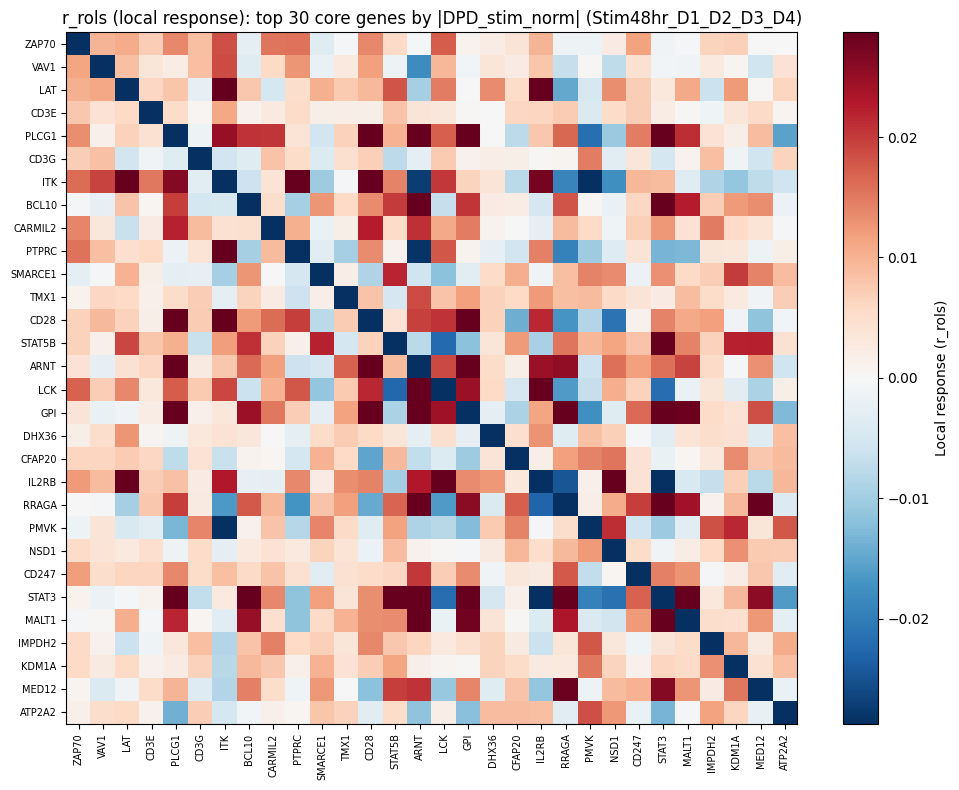

Saved: ../Results/Stim48hr/singlecell/r_rols_heatmap_top30_Stim48hr_D1_D2_D3_D4.png


In [14]:
top_genes = node_df.reindex(
    node_df['DPD_stim_norm'].abs().sort_values(ascending=False).index
)['gene'].head(TOP_N_GRAPH).tolist()

r_sub = r_rols.loc[top_genes, top_genes].to_numpy()
vmax = np.percentile(np.abs(r_sub[~np.eye(len(r_sub), dtype=bool)]), 95)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(r_sub, cmap='RdBu_r', vmin=-vmax, vmax=vmax, aspect='auto')
ax.set_xticks(range(len(top_genes)))
ax.set_yticks(range(len(top_genes)))
ax.set_xticklabels(top_genes, rotation=90, fontsize=7)
ax.set_yticklabels(top_genes, fontsize=7)
ax.set_title(f'r_rols (local response): top {TOP_N_GRAPH} core genes by |DPD_stim_norm| ({run_tag})')
plt.colorbar(im, ax=ax, label='Local response (r_rols)')
plt.tight_layout()
p = os.path.join(OUT_DIR, f'r_rols_heatmap_top{TOP_N_GRAPH}_{run_tag}.png')
plt.savefig(p, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {p}')

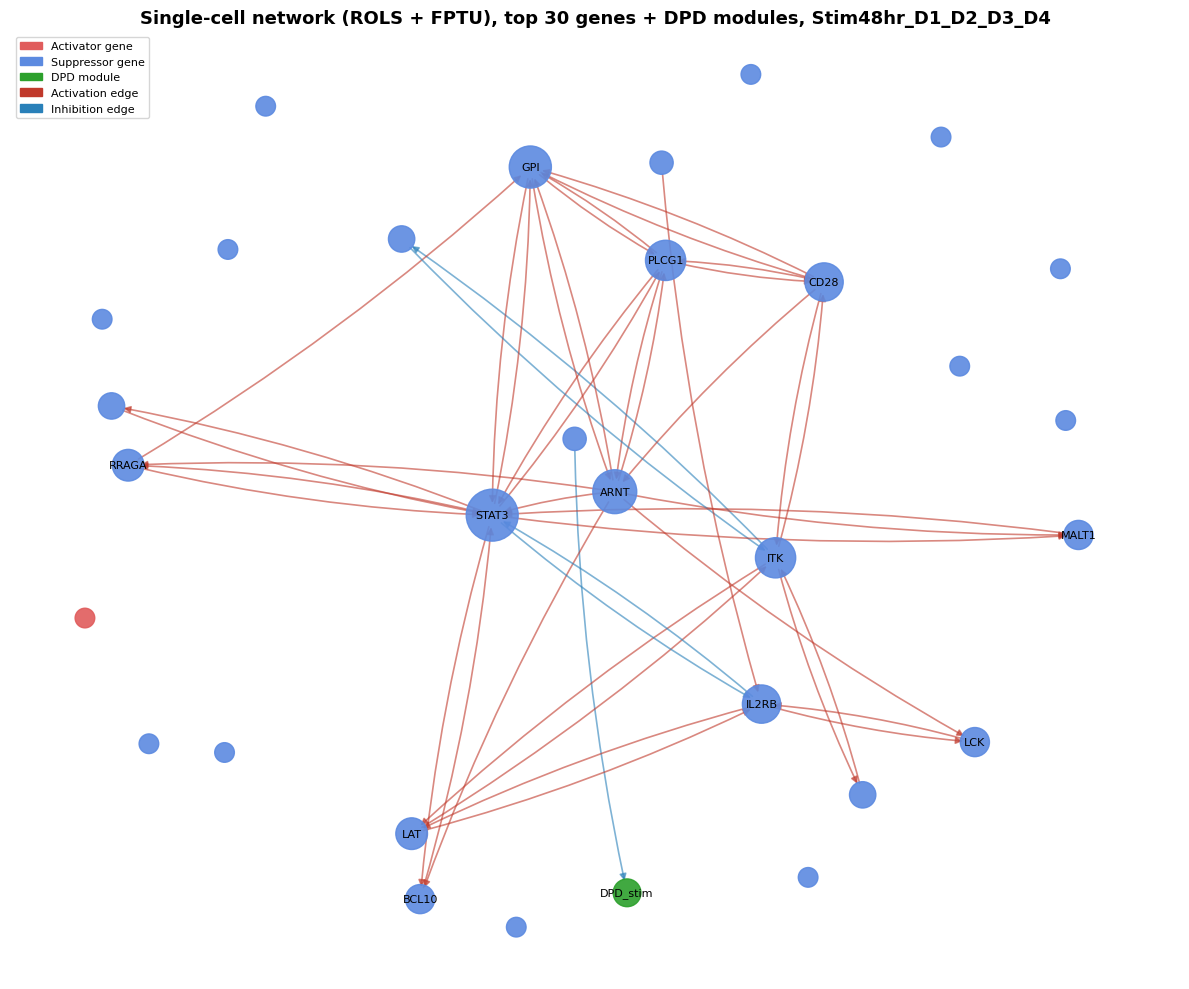

Saved: ../Results/Stim48hr/singlecell/network_graph_rols_Stim48hr_D1_D2_D3_D4.png


In [15]:
graph_nodes = top_genes + dpd_module_names

sub = r_rols.loc[top_genes, top_genes].to_numpy()
sub_off_diag = sub[~np.eye(len(top_genes), dtype=bool)]
sub_threshold = np.percentile(np.abs(sub_off_diag), STRENGTH_PERCENTILE)

graph_edges = strength_edges(r_rols.loc[top_genes, top_genes], top_genes, sub_threshold)
graph_edges = pd.concat([
    graph_edges,
    edges_fptu[edges_fptu['source'].isin(top_genes)],
], ignore_index=True)

G_plot = nx.DiGraph()
G_plot.add_nodes_from(graph_nodes)
for _, row in graph_edges.iterrows():
    G_plot.add_edge(row['source'], row['target'], edge_type=row['edge_type'], weight=abs(row['rols_strength']))

degree = dict(G_plot.degree())
node_colors = []
node_sizes = []
for gene in G_plot.nodes():
    if gene in dpd_module_names:
        node_colors.append('#2ca02c')
        node_sizes.append(400)
    else:
        role_activator = dpd_stim_lookup.get(gene, 0) > 0
        node_colors.append('#e05c5c' if role_activator else '#5c8ae0')
        node_sizes.append(200 + degree.get(gene, 0) * 80)

edge_colors = ['#c0392b' if G_plot.edges[e]['edge_type'] == 'activation' else '#2980b9' for e in G_plot.edges()]

fig, ax = plt.subplots(figsize=(12, 10))
pos = nx.spring_layout(G_plot, seed=42, k=0.4)
nx.draw_networkx_nodes(G_plot, pos, node_color=node_colors, node_size=node_sizes, alpha=0.9, ax=ax)
nx.draw_networkx_edges(G_plot, pos, edge_color=edge_colors, arrows=True, arrowsize=10,
                        width=1.2, alpha=0.6, connectionstyle='arc3,rad=0.05', ax=ax)
labels = {gene: gene for gene in G_plot.nodes() if degree.get(gene, 0) >= HUB_DEGREE_LABEL_MIN or gene in dpd_module_names}
nx.draw_networkx_labels(G_plot, pos, labels=labels, font_size=8, ax=ax)

legend_handles = [
    mpatches.Patch(color='#e05c5c', label='Activator gene'),
    mpatches.Patch(color='#5c8ae0', label='Suppressor gene'),
    mpatches.Patch(color='#2ca02c', label='DPD module'),
    mpatches.Patch(color='#c0392b', label='Activation edge'),
    mpatches.Patch(color='#2980b9', label='Inhibition edge'),
]
ax.legend(handles=legend_handles, loc='upper left', fontsize=8)
ax.set_title(f'Single-cell network (ROLS + FPTU), top {TOP_N_GRAPH} genes + DPD modules, {run_tag}',
             fontsize=13, fontweight='bold')
ax.axis('off')
plt.tight_layout()
p = os.path.join(OUT_DIR, f'network_graph_rols_{run_tag}.png')
plt.savefig(p, dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved: {p}')

### 11. Save

In [16]:
edges_df.to_csv(os.path.join(OUT_DIR, f'edges_{run_tag}.csv'), index=False)
edges_df.to_csv(os.path.join(OUT_DIR, f'edges_{run_tag}_cytoscape.txt'), sep='\t', index=False)
print('Saved: edges')

node_path = os.path.join(OUT_DIR, f'nodes_annotated_{run_tag}.csv')
node_df.to_csv(node_path, index=False)
print(f'Saved: {node_path}')

rols_vs_pseudo.to_csv(os.path.join(OUT_DIR, f'rols_vs_pseudobulk_{run_tag}.csv'), index=False)
print('Saved: rols_vs_pseudobulk')

validation_summary.to_csv(os.path.join(OUT_DIR, f'validation_string_trrust_{run_tag}.csv'), index=False)
print('Saved: validation_string_trrust')
if not checkpoint_detail.empty:
    checkpoint_detail.to_csv(os.path.join(OUT_DIR, f'validation_checkpoint_genes_{run_tag}.csv'), index=False)
    print('Saved: validation_checkpoint_genes')

recap_table.to_csv(os.path.join(OUT_DIR, f'recap_table_{run_tag}.csv'), index=False)
print('Saved: recap_table')

print(f'\nDone, {run_tag}')
print(f'Outputs in: {OUT_DIR}')

Saved: edges
Saved: ../Results/Stim48hr/singlecell/nodes_annotated_Stim48hr_D1_D2_D3_D4.csv
Saved: rols_vs_pseudobulk
Saved: validation_string_trrust
Saved: recap_table

Done, Stim48hr_D1_D2_D3_D4
Outputs in: ../Results/Stim48hr/singlecell
